In [2]:
import pandas as pd
inv_df = pd.read_csv("../data/raw/08_investor_transactions.csv")
inv_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [3]:
inv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [4]:
inv_df.isnull().sum()

investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

In [5]:
inv_df.duplicated().sum()

np.int64(0)

In [6]:
inv_df.describe()


,amfi_code,amount_inr,annual_income_lakh
count,32778.000000,32778.000000,32778.000000
mean,120264.617518,107437.318628,26.181219
std,14370.205345,150415.905084,20.805425
min,100016.000000,400.000000,3.000000
25%,118632.000000,3153.000000,10.600000
50%,119551.000000,17782.500000,19.700000
75%,120843.000000,189324.250000,37.400000
max,149324.000000,597498.000000,99.700000


In [7]:
inv_df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

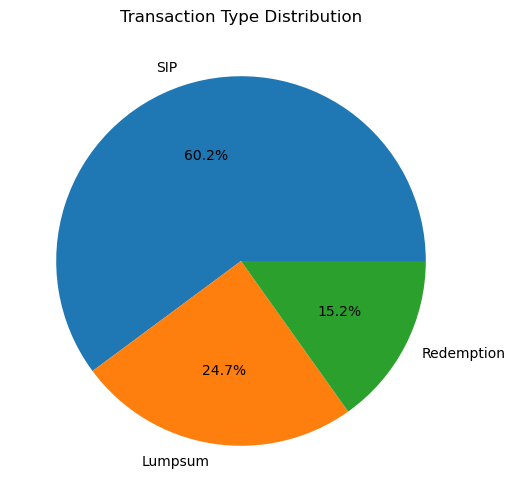

In [8]:
import matplotlib.pyplot as plt

inv_df['transaction_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Transaction Type Distribution")
plt.ylabel("")
plt.show()

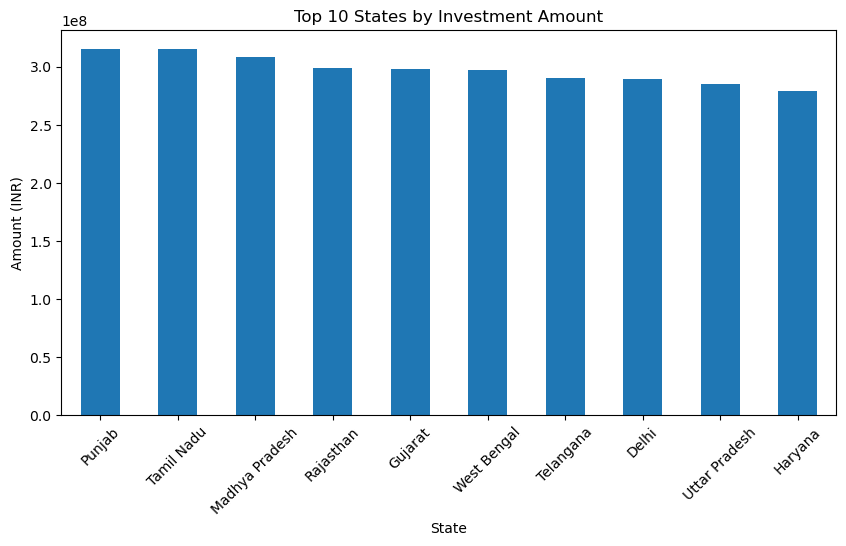

In [9]:
top_states = inv_df.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')

plt.title("Top 10 States by Investment Amount")
plt.xlabel("State")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=45)
plt.show()

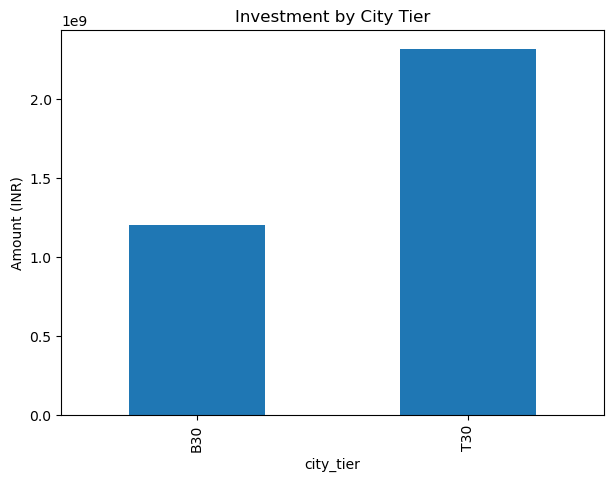

In [10]:
inv_df.groupby('city_tier')['amount_inr'].sum().plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Investment by City Tier")
plt.ylabel("Amount (INR)")
plt.show()

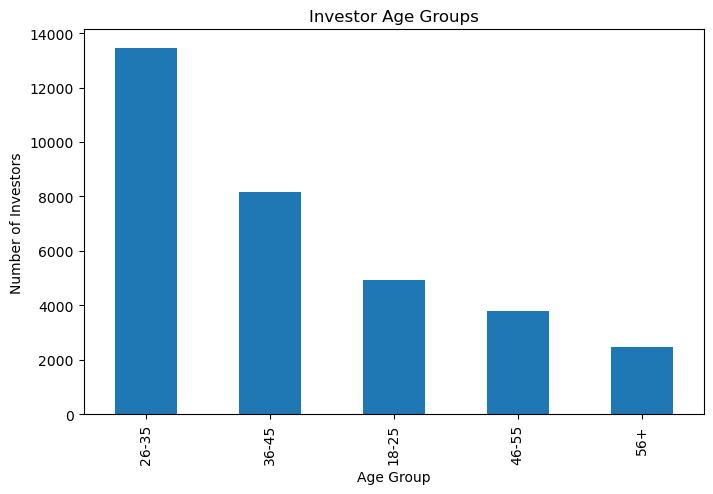

In [11]:
inv_df['age_group'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Investor Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")
plt.show()

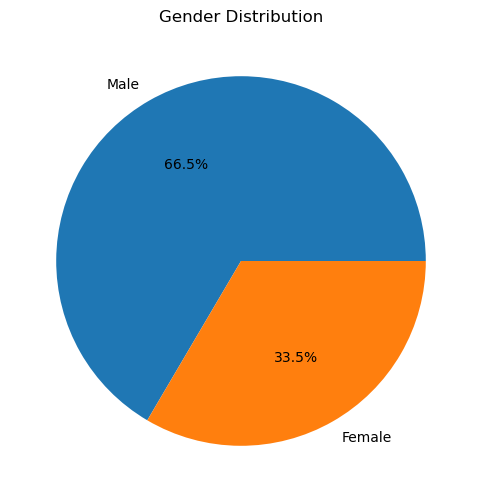

In [12]:
inv_df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

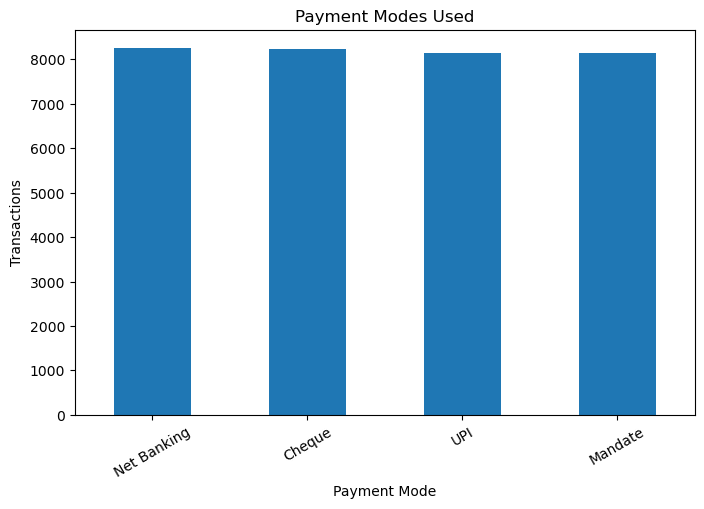

In [13]:
inv_df['payment_mode'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Payment Modes Used")
plt.xlabel("Payment Mode")
plt.ylabel("Transactions")
plt.xticks(rotation=30)
plt.show()

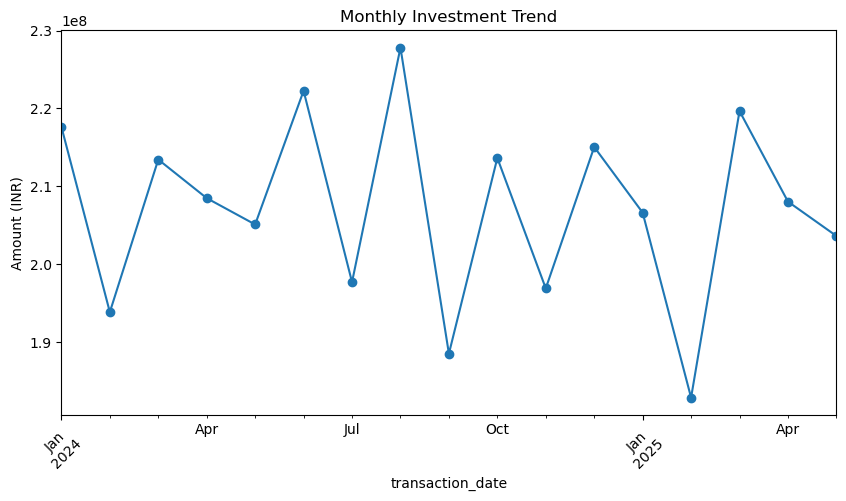

In [14]:
inv_df['transaction_date'] = pd.to_datetime(inv_df['transaction_date'])

monthly = inv_df.groupby(
    inv_df['transaction_date'].dt.to_period('M')
)['amount_inr'].sum()

monthly.plot(
    figsize=(10,5),
    marker='o'
)

plt.title("Monthly Investment Trend")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=45)
plt.show()

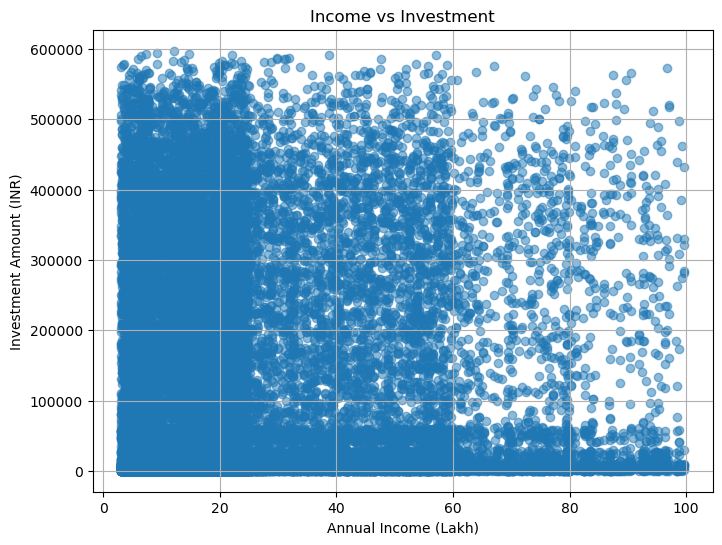

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    inv_df['annual_income_lakh'],
    inv_df['amount_inr'],
    alpha=0.5
)

plt.xlabel("Annual Income (Lakh)")
plt.ylabel("Investment Amount (INR)")
plt.title("Income vs Investment")
plt.grid(True)
plt.show()

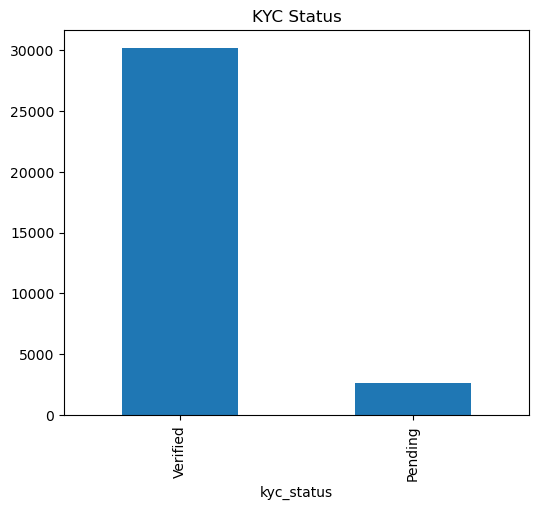

In [17]:
inv_df['kyc_status'].value_counts().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title("KYC Status")
plt.show()

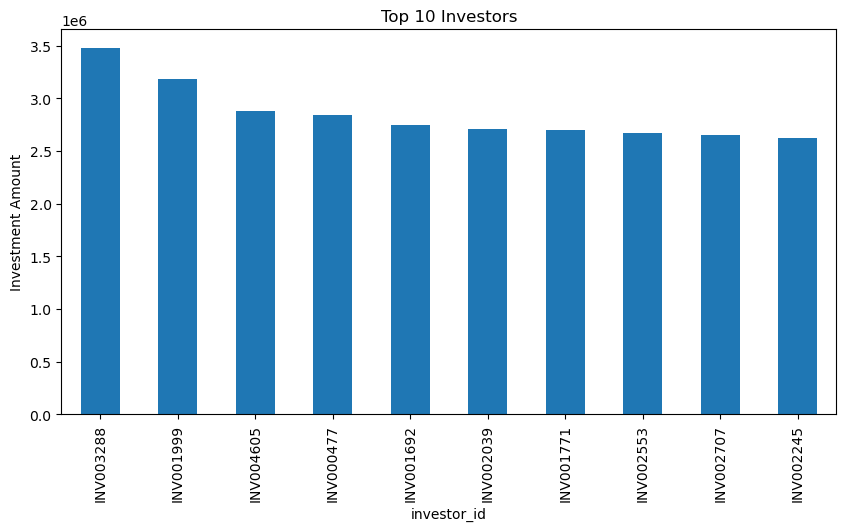

In [18]:
top = inv_df.groupby('investor_id')['amount_inr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top.plot(kind='bar')

plt.title("Top 10 Investors")
plt.ylabel("Investment Amount")
plt.show()

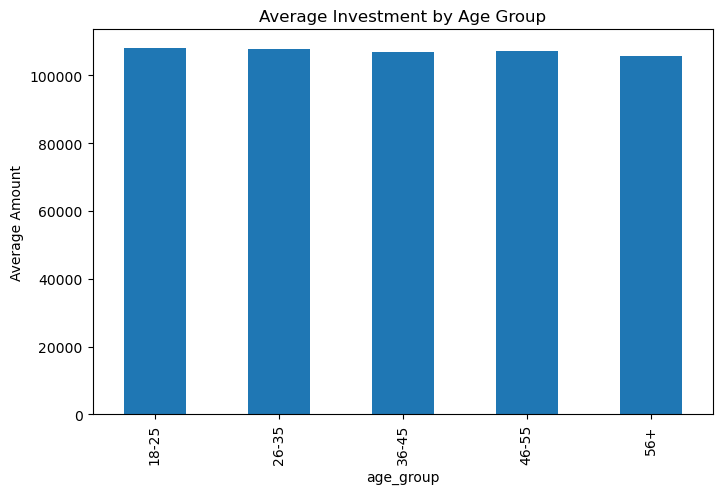

In [19]:
avg = inv_df.groupby('age_group')['amount_inr'].mean()

plt.figure(figsize=(8,5))
avg.plot(kind='bar')

plt.title("Average Investment by Age Group")
plt.ylabel("Average Amount")
plt.show()

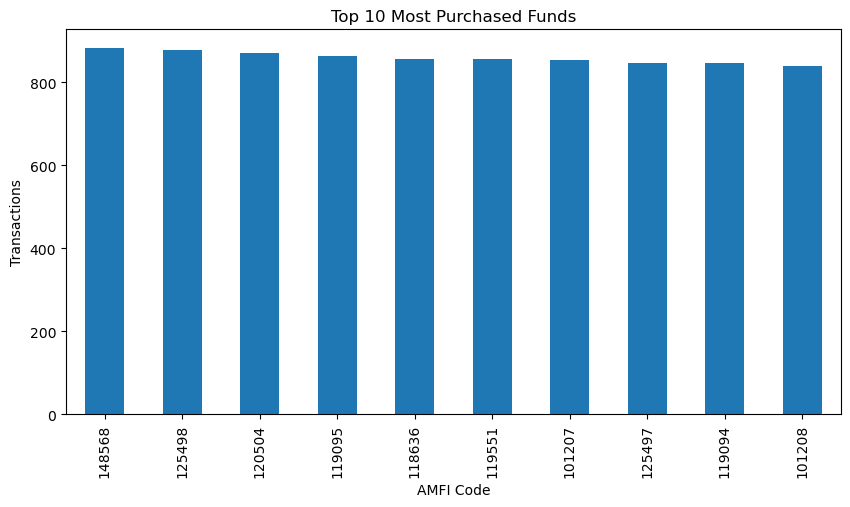

In [20]:
popular = inv_df['amfi_code'].value_counts().head(10)

plt.figure(figsize=(10,5))
popular.plot(kind='bar')

plt.title("Top 10 Most Purchased Funds")
plt.xlabel("AMFI Code")
plt.ylabel("Transactions")
plt.show()